# Environment setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
train_raw=pd.read_csv("train_raw.csv")



# Phase 1

* Verified your data infrastructure and folder setup.
* Audited the structural shapes of the file.
* Discovered that every station has the exact same row count ($26,304$ rows).

* Documented where the missing values live across all 12 stations.
 * Established a time-series safe validation plan.



# Structured view of log

In [3]:
#dataset dimensions

print(f"Total columns found: {train_raw.shape[1]}")
print(f"Total rows found:    {train_raw.shape[0]:,}")

Total columns found: 18
Total rows found:    315,648


### Structural Overview

 information log showing us the data types of each columnand how much memory the dataset takes.


In [4]:
# Check data types
train_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 315648 entries, 0 to 315647
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       315648 non-null  int64  
 1   year     315648 non-null  int64  
 2   month    315648 non-null  int64  
 3   day      315648 non-null  int64  
 4   hour     315648 non-null  int64  
 5   PM2.5    309276 non-null  float64
 6   PM10     311033 non-null  float64
 7   SO2      308661 non-null  float64
 8   NO2      305989 non-null  float64
 9   CO       297542 non-null  float64
 10  O3       305471 non-null  float64
 11  TEMP     315469 non-null  float64
 12  PRES     315468 non-null  float64
 13  DEWP     315464 non-null  float64
 14  RAIN     315472 non-null  float64
 15  wd       314973 non-null  object 
 16  WSPM     315470 non-null  float64
 17  station  315648 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 43.3+ MB


### Missing Values


---


checks every single column and calculates exactly how many blank records exist, sorted from worst to best

In [5]:
missing_counts=train_raw.isnull().sum()


# Display only the columns that have missing gaps
missing_counts[missing_counts>0].sort_values(ascending=False)

CO       18106
O3       10177
NO2       9659
SO2       6987
PM2.5     6372
PM10      4615
wd         675
DEWP       184
PRES       180
TEMP       179
WSPM       178
RAIN       176
dtype: int64

### Monitoring **Station**

---

distribution

THe log states that data is gathered from 12 distint station ,
Let's make sure all 12 stations are evenly represented with the exact same amount of rows.

In [6]:
# Verify how many records are logged per monitoring site

train_raw['station'].value_counts()

station
Aotizhongxin     26304
Changping        26304
Dingling         26304
Dongsi           26304
Guanyuan         26304
Gucheng          26304
Huairou          26304
Nongzhanguan     26304
Shunyi           26304
Tiantan          26304
Wanliu           26304
Wanshouxigong    26304
Name: count, dtype: int64

### Visualizing a Sample Snapshot
look at the actual values inside the first 5 lines of the table


In [7]:
# Display the first 5 rows of the DataFrame

train_raw.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


### Analyzing Missing Data by Station

In [8]:
# Calculate the percentage of missing values for each columnon
missing_pct_by_station = (
    train_raw.isnull().groupby(train_raw['station']).mean() * 100
)

# Isolate the main pollutant and weather columns to make the table clean and easy to read
target_columns = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
station_missing_profile = missing_pct_by_station[target_columns]

# Display the styled table directly in Jupyter
station_missing_profile.round(2)

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
station,,,,,,,,,,,
Aotizhongxin,2.84,2.30,3.02,3.09,6.18,5.54,0.01,0.01,0.01,0.01,0.01
Changping,2.51,1.84,1.86,2.07,5.22,1.87,0.13,0.13,0.13,0.13,0.12
Dingling,1.89,1.86,2.02,4.00,6.71,2.87,0.13,0.13,0.13,0.13,0.12
Dongsi,1.41,0.91,1.32,4.83,10.83,1.24,0.01,0.01,0.01,0.01,0.01
Guanyuan,1.62,1.10,1.43,2.13,5.83,4.04,0.01,0.01,0.01,0.01,0.01
Gucheng,1.87,1.06,1.57,2.01,4.85,2.41,0.13,0.13,0.13,0.10,0.12
Huairou,3.10,2.46,3.19,4.92,4.58,3.72,0.13,0.13,0.13,0.14,0.14
Nongzhanguan,1.85,1.25,1.28,1.97,3.68,1.48,0.01,0.01,0.01,0.01,0.01
Shunyi,2.23,1.05,3.31,3.53,6.67,2.19,0.13,0.13,0.14,0.13,0.13


### The Trap of Missing Timestamps

---
* We are checking that what if the logging hardware completely skips recording those hours. The spreadsheet jumps from 2:00 AM straight to 6:00 AM
this might be cause broken time gap

* glitchy database mergers or sensor logs write the exact same hour twice

* calculate expected hours : purpose ;Find out how many hourly records each station should have


*  check duplicate time stamp: may be  our 24-hour windows might contain the same hour twice,


In [9]:
#Create a proper date range
expected_hours = pd.date_range(start="2013-03-01 00:00:00", end="2016-02-29 23:00:00", freq="h")
print(f"Expected number of hours per station: {len(expected_hours)}")

Expected number of hours per station: 26304


In [10]:
#checking whether log sensed  no hour was accidentally recorded twice or not

duplicates = train_raw.duplicated(subset=['station', 'year', 'month', 'day', 'hour']).sum()
print(f"Total duplicate rows found: {duplicates}")

Total duplicate rows found: 0


# Cleaning the gaps

---
imputation process



*   groupby 'station' we used this to sepearte the log data of diffrent station to ensure that data of one station steal from next  station first hour


*   forwardfill: when it sees the NaN copies the values from the row directly above from it

*   backwardfill:when it sees the NaN copies the values from the row directly below from it


*   forwardfill strips the text column to focus on numbers so we have to again attach the station column again it copy and paste from our sorted copy





In [11]:
#train_clean=train_raw.copy()

#Sorting the Timeline
#train_clean = train_clean.sort_values(by=['station', 'year', 'month', 'day', 'hour']).reset_index(drop=True)

#  Apply forward fill (carry last hour forward), then backward fill (catch anything missing at row 0)
# We group by station so data from one station never accidentally bleeds into another
#  Apply Forward Fill per station (We use lambda to keep the dataframe structure intact)
#columns_to_fill = [c for c in train_clean.columns if c != 'station']
#train_clean[columns_to_fill] = train_clean.groupby('station', group_keys=False)[columns_to_fill].ffill()
#train_clean[columns_to_fill] = train_clean.groupby('station', group_keys=False)[columns_to_fill].bfill()


#re     attach the text column station
#train_clean['station'] = train_raw.sort_values(by=['station', 'year', 'month', 'day', 'hour'])['station'].values


In [12]:
train_clean = train_raw.copy()

#  Create one real time column time-series work is easier and safer with one real datetime column.
train_clean['datetime'] = pd.to_datetime(
    train_clean[['year', 'month', 'day', 'hour']]
)

#  Sort correctly(24-hour windows must follow correct time order)
train_clean = train_clean.sort_values(
    by=['station', 'datetime']
).reset_index(drop=True)

# Check duplicates before removing
duplicates = train_clean.duplicated(
    subset=['station', 'datetime']
).sum()

print("Duplicate station-hour rows:", duplicates)

#  Remove duplicate station-hour rows
#This keeps only one row for each station-hour.

train_clean = train_clean.drop_duplicates(
    subset=['station', 'datetime']
)

# Add missing hourly rows for each station
fixed_station_list = []

for station_name, station_data in train_clean.groupby('station'):

    station_data = station_data.set_index('datetime').sort_index()

    full_hours = pd.date_range(
        start=station_data.index.min(),
        end=station_data.index.max(),
        freq='h'
    )
    #Insert missing hours

    station_data = station_data.reindex(full_hours)

    station_data['station'] = station_name

    fixed_station_list.append(station_data)

train_clean = pd.concat(fixed_station_list).reset_index()
train_clean = train_clean.rename(columns={'index': 'datetime'})

#  Recreate year/month/day/hour after adding missing rows
train_clean['year'] = train_clean['datetime'].dt.year
train_clean['month'] = train_clean['datetime'].dt.month
train_clean['day'] = train_clean['datetime'].dt.day
train_clean['hour'] = train_clean['datetime'].dt.hour



#  Fill number columns, Because only numbers can use interpolation. we use only for numeric columns
numeric_cols = train_clean.select_dtypes(include=['int64', 'float64']).columns

#Fill numeric missing values
train_clean[numeric_cols] = (
    train_clean
    .groupby('station')[numeric_cols]
    .transform(lambda col: col.interpolate().ffill().bfill())
)

#  Fill wind direction text column
#so we copy previous/next wind direction.
train_clean['wd'] = (
    train_clean
    .groupby('station')['wd']
    .transform(lambda col: col.ffill().bfill())
)

#  Final check
print("Remaining missing values:", train_clean.isnull().sum().sum())
print("Final shape:", train_clean.shape)

Duplicate station-hour rows: 0
Remaining missing values: 0
Final shape: (315648, 19)


In [13]:
print("Remaining missing values:", train_clean.isnull().sum().sum())

Remaining missing values: 0


# feature engineering

---

* step: 1
  * Flattening the Spikes(like 999.) with a natural Logarithm ;compresses large values.

* step:2
   * Bending the Number Line into a Circle
   * No Infinite Growth
   * Consistent Mathematical Distance(between continues intervel)

* step:3
     * Computers need numbers, Models Can't Read "Northeast"
* step:4:Weather Physics Interaction

    * Instead of forcing the model to discover this relationship itself, you provide it directly.

    *  When the weather gap is wide: The air is dry and clear. The smoke can rise high into the sky and blow away cleanly.

   * When the weather gap is zero: A heavy fog blanket traps everything. The city's smoke can't rise. It gets caught in the heavy fog right at the ground, exactly where the pollution sensors are counting it.


In [14]:
# Display all unique values in the 'PM2.5' column
print("Unique PM2.5 values:")
display(train_clean['PM2.5'].unique())



Unique PM2.5 values:


array([  4.,   8.,   7., ..., 857., 748., 662.])

In [15]:
# Find the  maximum PM2.5 value
max_pm25 = train_clean['PM2.5'].max()
# Find the  minimum PM2.5 value
min_pm25 = train_clean['PM2.5'].min()

print(f"The maximum PM2.5 value ({train_raw['PM2.5'].max()}) ")
print(f"The minimum PM2.5 value ({train_raw['PM2.5'].min()}) ")



The maximum PM2.5 value (999.0) 
The minimum PM2.5 value (2.0) 


## minimize the squared error

In [16]:
# Create a fresh copy for feature engineering
train_features = train_clean.copy()

train_features['PM2.5_log'] = np.log1p(train_features['PM2.5'])

## Cyclical Time Encoding

In [17]:
# Convert Hour (0-23) into circular coordinates
train_features['hour_sin'] = np.sin(2 * np.pi * train_features['hour'] / 24.0)
train_features['hour_cos'] = np.cos(2 * np.pi * train_features['hour'] / 24.0)

# Convert Month (1-12) into circular coordinates
train_features['month_sin'] = np.sin(2 * np.pi * train_features['month'] / 12.0)
train_features['month_cos'] = np.cos(2 * np.pi * train_features['month'] / 12.0)

## Deconstructing Wind Directions into Math Vectors

In [18]:
wd_angles = {
    'N': 0, 'NNE': 22.5, 'NE': 45, 'ENE': 67.5,
    'E': 90, 'ESE': 112.5, 'SE': 135, 'SSE': 157.5,
    'S': 180, 'SSW': 202.5, 'SW': 225, 'WSW': 247.5,
    'W': 270, 'WNW': 292.5, 'NW': 315, 'NNW': 337.5
}
# Convert compass degrees to radians
wd_radians = train_features['wd'].map(wd_angles).fillna(0) * (np.pi / 180.0)

# Generate X and Y mathematical wind speed vectors
train_features['wind_x'] = train_features['WSPM'] * np.cos(wd_radians)
train_features['wind_y'] = train_features['WSPM'] * np.sin(wd_radians)

## create a new column  Dew Point Depression

---
The model's brain doesn't inherently know that two temp values being so close together means a heavy fog trap has formed.
we hand the model a single, clear number. Whenever that number gets close to 0, the model instantly realizes fog  has formed pm_2-5 goes high

In [19]:
# giving the number to  model to realize immediately when pm2.5 goes high

train_features['dew_point_depression'] = train_features['TEMP'] - train_features['DEWP']

In [20]:
# Remove row ID and text wind direction so the model doesn't crash
columns_to_drop = ['No', 'wd']
train_features = train_features.drop(columns=columns_to_drop)


In [21]:
train_features.head()

,datetime,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,...,WSPM,station,PM2.5_log,hour_sin,hour_cos,month_sin,month_cos,wind_x,wind_y,dew_point_depression
0,2013-03-01 00:00:00,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,...,4.4,Aotizhongxin,1.609438,0.000000,1.000000,1.0,6.123234e-17,4.065070,-1.683807,18.1
1,2013-03-01 01:00:00,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,...,4.7,Aotizhongxin,2.197225,0.258819,0.965926,1.0,6.123234e-17,4.700000,0.000000,17.1
2,2013-03-01 02:00:00,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,...,5.6,Aotizhongxin,2.079442,0.500000,0.866025,1.0,6.123234e-17,5.173725,-2.143027,17.1
3,2013-03-01 03:00:00,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,...,3.1,Aotizhongxin,1.945910,0.707107,0.707107,1.0,6.123234e-17,2.192031,-2.192031,18.0
4,2013-03-01 04:00:00,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,...,2.0,Aotizhongxin,1.386294,0.866025,0.500000,1.0,6.123234e-17,2.000000,0.000000,17.5


## extra ft

### weekend feature

---
why

*  Traffic changes.

* Industrial activity changes.
*  Human behaviour changes.

*   Pollution often differs on weekends.




In [22]:
#Find the day of the week

train_features['day_of_week']=train_features['datetime'].dt.dayofweek
train_features[['datetime', 'day_of_week']].head(120)

,datetime,day_of_week
0,2013-03-01 00:00:00,4
1,2013-03-01 01:00:00,4
2,2013-03-01 02:00:00,4
3,2013-03-01 03:00:00,4
4,2013-03-01 04:00:00,4
...,...,...
115,2013-03-05 19:00:00,1
116,2013-03-05 20:00:00,1
117,2013-03-05 21:00:00,1
118,2013-03-05 22:00:00,1


In [23]:

# Saturday (5) and Sunday (6) become 1
train_features['is_weekend'] = (
    train_features['day_of_week'] >= 5
).astype(int)




In [24]:
#verify
train_features[['datetime',
                'day_of_week',
                'is_weekend']].head(20)

,datetime,day_of_week,is_weekend
0,2013-03-01 00:00:00,4,0
1,2013-03-01 01:00:00,4,0
2,2013-03-01 02:00:00,4,0
3,2013-03-01 03:00:00,4,0
4,2013-03-01 04:00:00,4,0
5,2013-03-01 05:00:00,4,0
6,2013-03-01 06:00:00,4,0
7,2013-03-01 07:00:00,4,0
8,2013-03-01 08:00:00,4,0
9,2013-03-01 09:00:00,4,0


In [25]:
#drop day_of_week
train_features=train_features.drop(columns=['day_of_week'])

In [26]:
train_features.columns

Index(['datetime', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2',
       'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM', 'station',
       'PM2.5_log', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'wind_x',
       'wind_y', 'dew_point_depression', 'is_weekend'],
      dtype='object')

### Rain indicator

---
transforming raw measurements into more meaningful information

We created a binary feature from the RAIN column to indicate whether rainfall occurred during a particular hour. While the original RAIN feature measures the amount of rainfall, the binary indicator provides the model with a simple signal distinguishing dry and rainy conditions. Rainfall can remove airborne PM2.5 particles through wet deposition, so this feature may help the model recognize conditions associated with lower pollution levels.


In [27]:
# Create a binary rain indicator
train_features['is_raining']=(train_features['RAIN']>0).astype(int)

In [28]:
train_features[['RAIN','is_raining']].head(15)

,RAIN,is_raining
0,0.0,0
1,0.0,0
2,0.0,0
3,0.0,0
4,0.0,0
5,0.0,0
6,0.0,0
7,0.0,0
8,0.0,0
9,0.0,0


In [29]:
#number of samples and how common rainy hours are in the dataset.
(train_features['is_raining']
 .value_counts(normalize=True) * 100).round(2)

is_raining
0    96.02
1     3.98
Name: proportion, dtype: float64

### intereaction features

In [30]:
# Temperature × Wind Speed
train_features['temp_wind'] = (
    train_features['TEMP']
    * train_features['WSPM']
)

# Pressure × Wind Speed
train_features['pressure_wind'] = (
    train_features['PRES']
    * train_features['WSPM']
)

# Dew Point Depression × Wind Speed
train_features['fog_wind'] = (
    train_features['dew_point_depression']
    * train_features['WSPM']
)

### checking the final output of features

In [31]:
# Check the final dataset shape
print("Shape:", train_features.shape)

# Display the first 5 rows
train_features.head()

# Check for any remaining missing values
print("\nRemaining Missing Values:")
print(train_features.isnull().sum().sum())

# List all columns
print("\nFinal Features:")
print(train_features.columns.tolist())

Shape: (315648, 30)

Remaining Missing Values:
0

Final Features:
['datetime', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM', 'station', 'PM2.5_log', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'wind_x', 'wind_y', 'dew_point_depression', 'is_weekend', 'is_raining', 'temp_wind', 'pressure_wind', 'fog_wind']


# slicing 24 hour window


---

 adding rolling statistics and lag features.

sliding window also add:The reason is that your next phase is building 24-hour windows. Once we decide exactly how those windows are constructed, we can add rolling statistics and lag features in the most appropriate place without creating redundant features or accidentally introducing information from the future. That keeps your pipeline clean and avoids data leakage.

## choose the input features


*   Clean numeric feature list ready for window building
*   Remove station: text column, cannot go directly into model



In [32]:
# Columns needed for ordering/grouping, not for model input
helper_cols = ['datetime', 'station']

# Target we want to predict
target_col = 'PM2.5'

# Columns to remove from model input
remove_from_features = [
    'datetime',
    'station',
    'year',
    'month',
    'day',
    'hour',
    'day_of_week'
]

# Final input feature columns
feature_cols = [
    col for col in train_features.columns
    if col not in remove_from_features
]

print("Number of model input features:", len(feature_cols))
print(feature_cols)

Number of model input features: 24
['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM', 'PM2.5_log', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'wind_x', 'wind_y', 'dew_point_depression', 'is_weekend', 'is_raining', 'temp_wind', 'pressure_wind', 'fog_wind']


## sort the log data

In [33]:
train_features=train_features.sort_values(by=helper_cols).reset_index(drop=True)

## sliding window

In [34]:
WINDOW_SIZE=24
def create_windows(data,feature_cols,target_col,window_size=24):

  X_windows = []
  y_targets = []


  #it separates the station
  for station_name, station_data in data.groupby(helper_cols[1]):

       #we sort again inside each station
      station_data = station_data.sort_values(helper_cols[0]).reset_index(drop=True)

      X_station = station_data[feature_cols].to_numpy()
      y_station = station_data[target_col].to_numpy()
      for i in range(len(station_data) - window_size):

            X_windows.append(X_station[i:i + window_size])

            y_targets.append(y_station[i + window_size])

  X = np.array(X_windows)
  y = np.array(y_targets)
  return X, y

In [35]:
X, y = create_windows(
    data=train_features,
    feature_cols=feature_cols,
    target_col=target_col,
    window_size=WINDOW_SIZE
)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (315360, 24, 24)
y shape: (315360,)


### Rolling statistics

---
* used for only baseline model here
* some advanced lstm models used two imput(sequence X, rolling statics)



In [36]:
# Find the PM2.5 column index inside the feature list
pm25_index = feature_cols.index('PM2.5')

# Extract PM2.5 values from each 24-hour window
pm25_windows = X[:, :, pm25_index]

# Compute 24-hour rolling statistics for each window
pm25_mean_24 = pm25_windows.mean(axis=1)
pm25_std_24 = pm25_windows.std(axis=1)
pm25_min_24 = pm25_windows.min(axis=1)
pm25_max_24 = pm25_windows.max(axis=1)

# Combine them into one rolling feature matrix
rolling_features = np.column_stack([
    pm25_mean_24,
    pm25_std_24,
    pm25_min_24,
    pm25_max_24
])

# Store names for explanation/reporting
rolling_feature_cols = [
    'pm25_mean_24h',
    'pm25_std_24h',
    'pm25_min_24h',
    'pm25_max_24h'
]

print("Rolling features shape:", rolling_features.shape)
print("Rolling feature columns:", rolling_feature_cols)

Rolling features shape: (315360, 4)
Rolling feature columns: ['pm25_mean_24h', 'pm25_std_24h', 'pm25_min_24h', 'pm25_max_24h']


## Chronological Train/Validation Split

---
* Time-series data must be split chronologically
  * Because the default behavior of train_test_split() is to shuffle the data.

    For time-series forecasting, shuffling mixes future observations into the training set, causing data leakage


In [37]:
# Use the first 80% of windows for training
split_index = int(len(X) * 0.80)

# Sequential data for Temporal Neural Networks
#the training inputs
X_train_seq = X[:split_index]
y_train = y[:split_index]

# Remaining 20% used for validation
X_val_seq = X[split_index:]
y_val = y[split_index:]

# Display dataset sizes
print("Training samples :", X_train_seq.shape[0])
print("Validation samples:", X_val_seq.shape[0])

print("\nTraining Input Shape :", X_train_seq.shape)
print("Training Target Shape:", y_train.shape)

print("\nValidation Input Shape :", X_val_seq.shape)
print("Validation Target Shape:", y_val.shape)

Training samples : 252288
Validation samples: 63072

Training Input Shape : (252288, 24, 24)
Training Target Shape: (252288,)

Validation Input Shape : (63072, 24, 24)
Validation Target Shape: (63072,)


### verifying the split ratio (train vs validation)

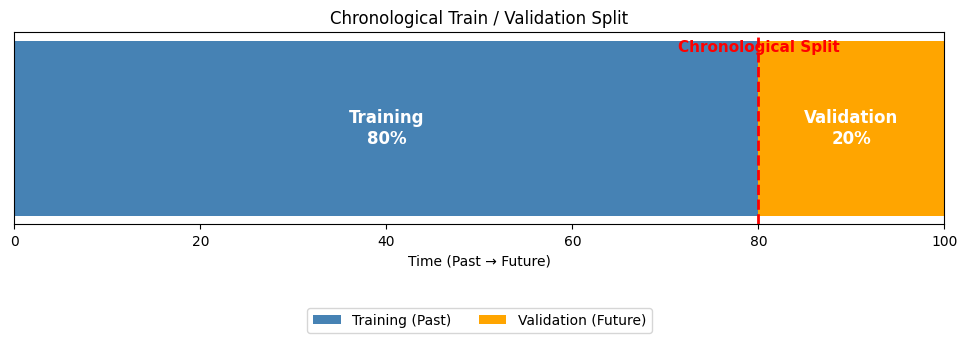

In [38]:


# Calculate percentages
train_pct = len(X_train_seq) / len(X) * 100
val_pct = len(X_val_seq) / len(X) * 100

plt.figure(figsize=(12,2.5))

# Training portion
plt.barh(
    y=0,
    width=train_pct,
    color='steelblue',
    label='Training (Past)'
)

# Validation portion
plt.barh(
    y=0,
    width=val_pct,
    left=train_pct,
    color='orange',
    label='Validation (Future)'
)

# Split line
plt.axvline(
    x=train_pct,
    color='red',
    linestyle='--',
    linewidth=2
)

# Labels inside bars
plt.text(
    train_pct/2,
    0,
    f"Training\n{train_pct:.0f}%",
    ha='center',
    va='center',
    color='white',
    fontsize=12,
    fontweight='bold'
)

plt.text(
    train_pct + val_pct/2,
    0,
    f"Validation\n{val_pct:.0f}%",
    ha='center',
    va='center',
    color='white',
    fontsize=12,
    fontweight='bold'
)

# Annotation
plt.text(
    train_pct,
    0.35,
    "Chronological Split",
    color='red',
    ha='center',
    fontsize=11,
    fontweight='bold'
)

# Formatting
plt.xlim(0,100)
plt.yticks([])
plt.xlabel("Time (Past → Future)")
plt.title("Chronological Train / Validation Split")
plt.legend(loc='lower center', bbox_to_anchor=(0.5,-0.6), ncol=2)

plt.show()

### Monitoring Station Distribution

why?

* Confirmed that all 12 monitoring stations remained in the dataset.
* Ensured no station was accidentally removed during cleaning
* Verified that each station contributes a similar number of hourly observations before constructing the 24-hour training windows.

In [39]:
station_summary = (
    train_features['station']
    .value_counts()
    .sort_index()
    .reset_index()
)

station_summary.columns = ['Monitoring Station', 'Number of Records']

display(station_summary)

,Monitoring Station,Number of Records
0,Aotizhongxin,26304
1,Changping,26304
2,Dingling,26304
3,Dongsi,26304
4,Guanyuan,26304
5,Gucheng,26304
6,Huairou,26304
7,Nongzhanguan,26304
8,Shunyi,26304
9,Tiantan,26304


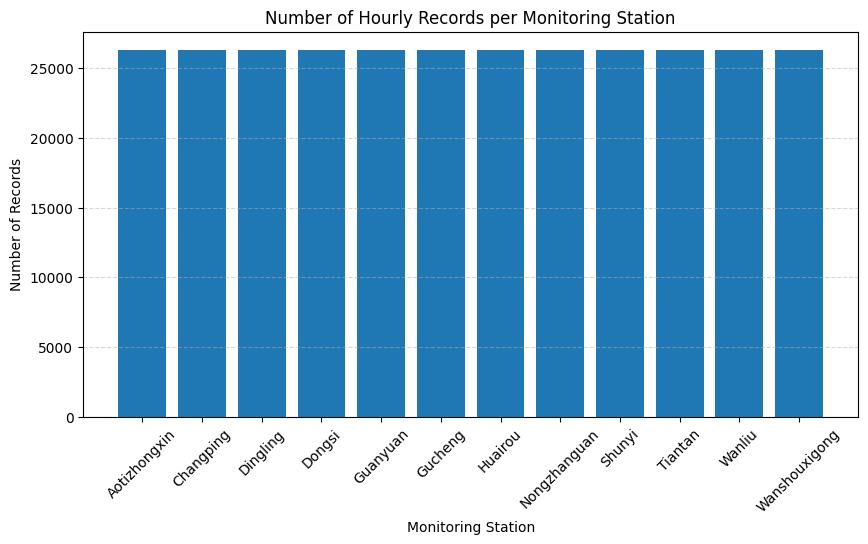

In [40]:


station_counts = (
    train_features['station']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10,5))

plt.bar(
    station_counts.index,
    station_counts.values
)

plt.title("Number of Hourly Records per Monitoring Station")
plt.xlabel("Monitoring Station")
plt.ylabel("Number of Records")

plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

# baseline models


---


*   not understand sequnce of 24 hours
*   give them rolling statics
*    flattedn window (2D)




## prepare baseline input data

---
Linear Regression/Random Forest sees table shape:
(samples, columns)


In [41]:
# Flatten sequence data for baseline models

X_train_flat = X_train_seq.reshape(X_train_seq.shape[0], -1) #(252288,576)
X_val_flat = X_val_seq.reshape(X_val_seq.shape[0], -1)

print("Baseline model input shapes:")
print("X_train_flat:", X_train_flat.shape)
print("X_val_flat:", X_val_flat.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

Baseline model input shapes:
X_train_flat: (252288, 576)
X_val_flat: (63072, 576)
y_train: (252288,)
y_val: (63072,)


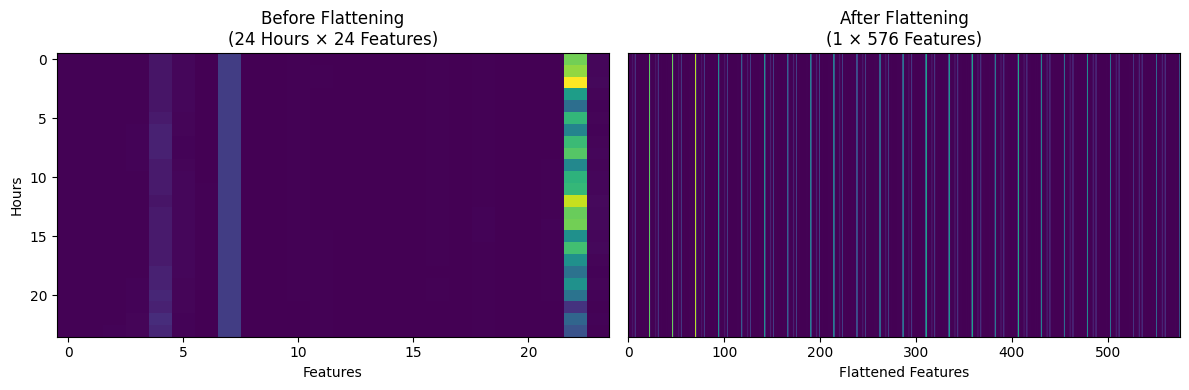

In [42]:
import matplotlib.pyplot as plt

sample = 0

plt.figure(figsize=(12,4))

# Before flattening
plt.subplot(1,2,1)
plt.imshow(X_train_seq[sample], aspect='auto')
plt.title("Before Flattening\n(24 Hours × 24 Features)")
plt.xlabel("Features")
plt.ylabel("Hours")

# After flattening
plt.subplot(1,2,2)
plt.imshow(X_train_flat[sample].reshape(1,-1), aspect='auto')
plt.title("After Flattening\n(1 × 576 Features)")
plt.xlabel("Flattened Features")
plt.yticks([])

plt.tight_layout()
plt.show()

* 3D(one window)

--- ---  ---24features --- --- ---

□□□□□□□□□□□□□□□□ -one hour

□□□□□□□□□□□□□□□□                                  
                                      
□□□□□□□□□□□□□□□□

24 rows

□□□□□□□□□□□□□□□□- 24 hour

---


*  2D(one window)


--- ---  ---24*24 features --- --- ---


  □□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□□


## linear regression

### import metrics and model

In [43]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


In [44]:
### Train linear Regression

In [45]:
linear_model = LinearRegression()
linear_model.fit(X_train_flat, y_train)

LinearRegression()

### Predict validation set

In [46]:
y_val_pred_lr = linear_model.predict(X_val_flat)

### Evaluate RMSE

In [47]:
rmse_lr = np.sqrt(mean_squared_error(y_val, y_val_pred_lr))


print("Linear Regression Results")
print("RMSE:", rmse_lr)

Linear Regression Results
RMSE: 18.5704744633947


## Random forest

In [49]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_flat, y_train)

y_val_pred_rf = rf_model.predict(X_val_flat)

rmse_rf = np.sqrt(mean_squared_error(y_val, y_val_pred_rf))
mae_rf = mean_absolute_error(y_val, y_val_pred_rf)

print("Random Forest Results")
print("RMSE:", rmse_rf)
print("MAE :", mae_rf)

Random Forest Results
RMSE: 18.27625655523285
MAE : 10.050136324377261


# grqadient boost
* huuuu